In [16]:
!pip install mglearn

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import mglearn


# Uncertainty Estimates

Uncertainty estimates express how confident a classifier is in its prediction. In scikit-learn, uncertainty can be obtained using decision_function, which returns real-valued confidence scores with arbitrary scale, or predict_proba, which returns normalized probabilities for each class. These estimates are crucial in applications where different types of classification errors have different real-world consequences.

In [18]:
X, y = make_circles(noise=0.25, factor=0.5, random_state=1)

In make_circles, the **factor** parameter specifies the ratio of the inner circle’s radius to the outer circle’s radius(factor = 0.5 → inner circle radius is 50% of the outer circle radius), controlling how close the two classes are.

In [19]:
# renaming the classes "blue" and "red" for illustration purposes
y_named = np.array(["blue", "red"])[y]

# we can call train_test_split with arbitrarily many arrays;
# all will be split in a consistent manner
X_train, X_test, y_train_named, y_test_named, y_train, y_test = train_test_split(X, y_named, y, random_state=0)

In [20]:
#gradient boosting model
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train_named)

GradientBoostingClassifier(random_state=0)

# The Decision Function

In the binary classification case, the return value of decision_function is of shape (n_samples,), and it returns one floating-point number for each sample.

In [21]:
print("X_test.shape: {}".format(X_test.shape))
print("Decision function shape: {}".format(gbrt.decision_function(X_test).shape))

X_test.shape: (25, 2)
Decision function shape: (25,)


This value encodes how strongly the model believes a data point to belong to the “positive” class, in this case class 1. Positive values indicate a preference for the positive class, and negative values indicate a preference for the “negative” (other) class.

In [22]:
# First few entries of decision_function
print("Decision function:", gbrt.decision_function(X_test)[:6])

Decision function: [ 4.13592603 -1.70169917 -3.95106099 -3.62609552  4.28986642  3.66166081]


In [23]:
print("Thresholded decision function:\n", gbrt.decision_function(X_test) > 0)
print("Predictions:\n", gbrt.predict(X_test))

Thresholded decision function:
 [ True False False False  True  True False  True  True  True False  True
  True False  True False False False  True  True  True  True  True False
 False]
Predictions:
 ['red' 'blue' 'blue' 'blue' 'red' 'red' 'blue' 'red' 'red' 'red' 'blue'
 'red' 'red' 'blue' 'red' 'blue' 'blue' 'blue' 'red' 'red' 'red' 'red'
 'red' 'blue' 'blue']


For binary classification, the “negative” class is always the first entry of the classes_ attribute, and the “positive” class is the second entry of classes_.

In [24]:
# Class labels that the model was trained on
print(gbrt.classes_)

['blue' 'red']


In [25]:
# make the boolean True/False into 0 and 1
greater_zero = (gbrt.decision_function(X_test) > 0).astype(int)
# use 0 and 1 as indices into classes_
pred = gbrt.classes_[greater_zero]
# pred is the same as the output of gbrt.predict
print("pred is equal to predictions:",
      np.all(pred == gbrt.predict(X_test)))

pred is equal to predictions: True


The range of decision_function can be arbitrary, and depends on the data and the model parameters.

In [26]:
decision_function = gbrt.decision_function(X_test)
print("Decision function minimum: {:.2f} maximum: {:.2f}".format(
      np.min(decision_function), np.max(decision_function)))

Decision function minimum: -7.69 maximum: 4.29


This arbitrary scaling makes the output of decision_function often hard to interpret.

Below example plots the decision_function for all points in the 2D plane using a color coding, next to a visualization of the decision boundary.

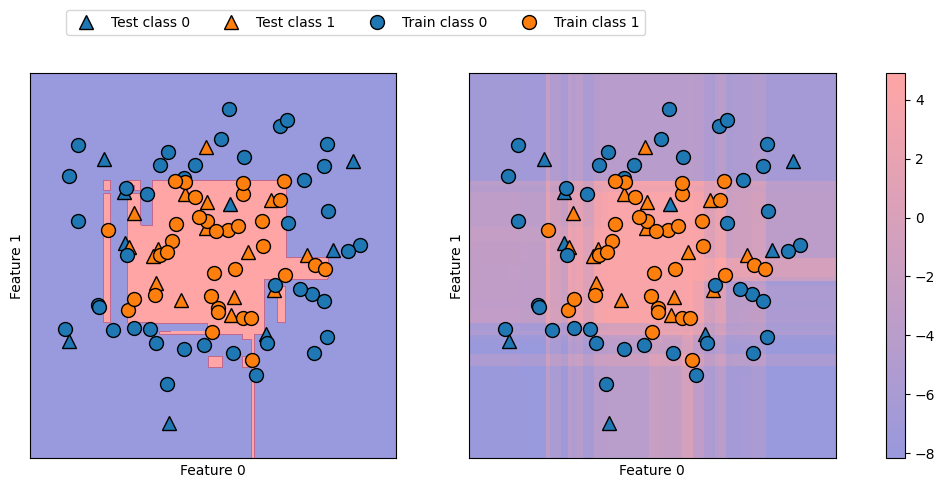

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
mglearn.tools.plot_2d_separator(gbrt, X, ax=axes[0], alpha=.4,
                                fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, X, ax=axes[1],
                                            alpha=.4, cm=mglearn.ReBl)

for ax in axes:
    # plot training and test points
    mglearn.discrete_scatter(X_test[:, 0], X_test[:, 1], y_test,
                             markers='^', ax=ax)
    mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train,
                             markers='o', ax=ax)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(["Test class 0", "Test class 1", "Train class 0",
                "Train class 1"], ncol=4, loc=(.1, 1.1))

Decision boundary (left) and decision function (right) for the model on the two-dimensional toy dataset.

Encoding not only the predicted outcome but also how certain the classifier is provides additional information.


# Predicting Probabilities

The output of predict_proba is a probability for each class, and is often more easily understood than the output of decision_function. It is always of shape (n_samples, 2) for binary classification.

In [28]:
print("Shape of probabilities:", gbrt.predict_proba(X_test).shape)

Shape of probabilities: (25, 2)


The first entry in each row is the estimated probability of the first class, and the second entry is the estimated probability of the second class. Because it is a probability, the output of predict_proba is always between 0 and 1, and the sum of the entries for both classes is always 1.

In [29]:
# First few entries of predict_proba
print("Predicted probabilities:")
print(gbrt.predict_proba(X_test[:6]))

Predicted probabilities:
[[0.01573626 0.98426374]
 [0.84575653 0.15424347]
 [0.98112869 0.01887131]
 [0.97407033 0.02592967]
 [0.01352142 0.98647858]
 [0.02504637 0.97495363]]


Because the probabilities for the two classes sum to 1, exactly one of the classes will be above 50% certainty. That class is the one that is predicted.

(Because the probabilities are floating-point numbers, it is unlikely that they will both be exactly 0.500. However, if that happens, the prediction is made at random)

 Below plot show the decision boundary on the dataset, next to the class probabilities for the class 1.

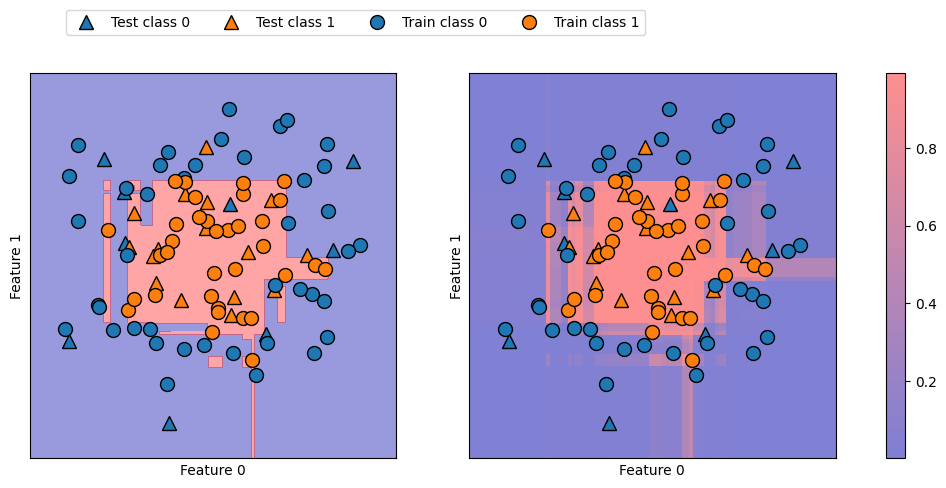

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mglearn.tools.plot_2d_separator(
    gbrt, X, ax=axes[0], alpha=.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(
    gbrt, X, ax=axes[1], alpha=.5, cm=mglearn.ReBl, function='predict_proba')

for ax in axes:
    # plot training and test points
    mglearn.discrete_scatter(X_test[:, 0], X_test[:, 1], y_test,
                             markers='^', ax=ax)
    mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train,
                             markers='o', ax=ax)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")
cbar = plt.colorbar(scores_image, ax=axes.tolist())
axes[0].legend(["Test class 0", "Test class 1", "Train class 0",
                "Train class 1"], ncol=4, loc=(.1, 1.1))

Decision boundary (left) and predicted probabilities for the gradient boosting model.

The boundaries in this plot are much more well-defined, and the small areas of uncertainty are clearly visible.
